# Build AQI Prediction Model

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [35]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

### Step 1: Select Features

In [36]:
# Read the dataset
Weather = pd.read_csv('../Datasets/Forecasting_Data.csv')
Weather.head()

,UpdatedAt,Country,CountryCode,State,StateCode,City,CityID,Latitude,Longitude,WeatherCondition,...,NO,NO2,O3,SO2,PM25,PM10,NH3,CreatedAt,Date,AQI_Category
0,2025-06-01 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,4.43,38.19,70.04,10.91,36.54,53.71,3.60,2025-06-01 12:00:00,2025-06-01,Satisfactory
1,2025-06-02 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Rain,...,8.74,20.16,42.95,7.57,48.00,68.64,14.81,2025-06-02 12:00:00,2025-06-02,Satisfactory
2,2025-06-03 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Thunderstorm,...,14.69,20.85,31.69,9.73,37.52,53.28,13.21,2025-06-03 12:00:00,2025-06-03,Satisfactory
3,2025-06-04 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clear,...,16.81,54.36,56.80,4.64,63.84,91.93,14.59,2025-06-04 12:00:00,2025-06-04,Moderate
4,2025-06-05 12:00:00,India,IN,Gujarat,GJ,Ahmedabad,1279233,23.0225,72.5714,Clouds,...,15.13,9.56,16.31,20.10,57.96,89.84,10.07,2025-06-05 12:00:00,2025-06-05,Moderate


In [37]:
Weather_Data = Weather.copy()

In [38]:
features = ['Temperature', 'Humidity', 'WindSpeed', 'PM25', 'PM10', 'NO2', 'SO2', 'CO']

X = Weather_Data[features]
y = Weather_Data['AQI']

### Step 2: Train-Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 3: Train Model

In [40]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)     

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### Step 4: Predict

In [41]:
y_pred = model.predict(X_test)

### Step 5: Evaluate

In [42]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.9430859035017694
MAE: 10.964996710526316


### Step 6: Show Model Performance

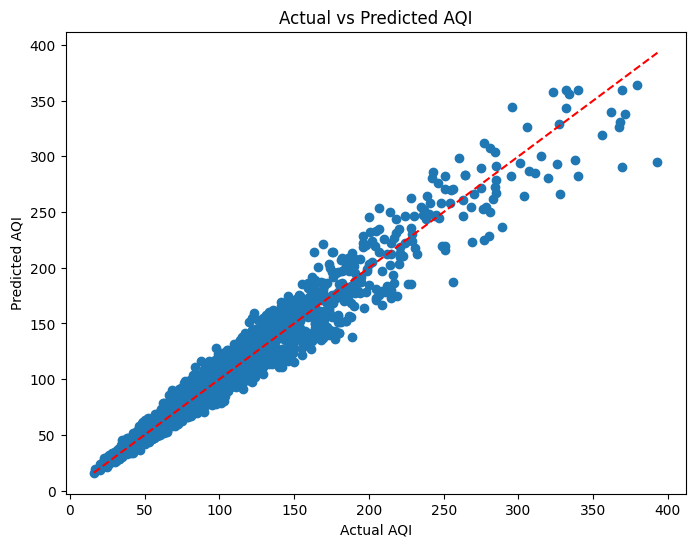

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

# Phase 3: Build AQI Forecasting

### Step 1: Create Future Input

In [44]:
future_weather = pd.DataFrame({
    'Temperature': [28],
    'Humidity': [75],
    'WindSpeed': [2.5],
    'PM25': [95],
    'PM10': [130],
    'NO2': [40],
    'SO2': [10],
    'CO': [800]
})

### Step 2: Predict Future AQI

In [45]:
future_aqi = model.predict(future_weather)
print('Predicted AQI:', future_aqi)

Predicted AQI: [179.655]


### Step 3: Convert AQI to Category

In [46]:
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    else:
        return "Severe"

print('Predicted AQI Category:', get_aqi_category(future_aqi[0]))

Predicted AQI Category: Moderate


In [47]:
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

model = RandomForestRegressor()
model.fit(X_train, y_train)

joblib.dump(model, 'aqi_model.pkl')

['aqi_model.pkl']

In [48]:
# Delete the existing model file if it exists
if os.path.exists('aqi_model.pkl'):
    os.remove('aqi_model.pkl')

### Step 4: Check the informations about the dataset

In [49]:
print(X.columns.tolist())

['Temperature', 'Humidity', 'WindSpeed', 'PM25', 'PM10', 'NO2', 'SO2', 'CO']


In [50]:
print("Weather Data Shape:", Weather_Data.shape)

Weather Data Shape: (7600, 37)


In [51]:
First_Date = Weather_Data['Date'].min()
Last_Date = Weather_Data['Date'].max()
print("Date Range:", First_Date, "to", Last_Date)

Date Range: 2025-06-01 to 2026-06-15


In [52]:
print("Number of Unique Dates:", Weather_Data['Date'].nunique())

Number of Unique Dates: 380


In [53]:
print("Number of Unique Cities:", Weather_Data['City'].nunique())

Number of Unique Cities: 20


In [54]:
count = Weather_Data['City'].value_counts().head(10)
print("Top 10 Cities by Data Points:")
count

Top 10 Cities by Data Points:


City
Ahmedabad    380
Bengaluru    380
Bhopal       380
Chennai      380
Delhi        380
Goa          380
Hyderabad    380
Jaipur       380
Kanpur       380
Kochi        380
Name: count, dtype: int64

### Step 5: Select a city "Kolkata" for AQI prediction

In [55]:
kolkata = Weather_Data[Weather_Data['City'] == 'Kolkata'].copy()
kolkata = kolkata.sort_values('Date')

In [56]:
forecast_df = kolkata[['Date', 'AQI']].copy()
forecast_df

,Date,AQI
3800,2025-06-01,101
3801,2025-06-02,71
3802,2025-06-03,84
3803,2025-06-04,136
3804,2025-06-05,167
...,...,...
4175,2026-06-11,106
4176,2026-06-12,140
4177,2026-06-13,131
4178,2026-06-14,72


### Step 6: For Actual Forecasting, we need to rename the columns to 'ds' and 'y' as required by Prophet

In [57]:
from prophet import Prophet
from prophet.serialize import model_to_json
import os

In [58]:
forecast_df.columns = ['ds', 'y']
forecast_df

,ds,y
3800,2025-06-01,101
3801,2025-06-02,71
3802,2025-06-03,84
3803,2025-06-04,136
3804,2025-06-05,167
...,...,...
4175,2026-06-11,106
4176,2026-06-12,140
4177,2026-06-13,131
4178,2026-06-14,72


### Step 7: Train the model

In [59]:
model = Prophet()
model.fit(forecast_df)

00:44:21 - cmdstanpy - INFO - Chain [1] start processing
00:44:21 - cmdstanpy - INFO - Chain [1] done processing


### Step 8 — Create Future Dates

In [60]:
future = model.make_future_dataframe(periods=30)

In [61]:
forecast = model.predict(future)

### Step 9 — Predict Any Date & Visualize

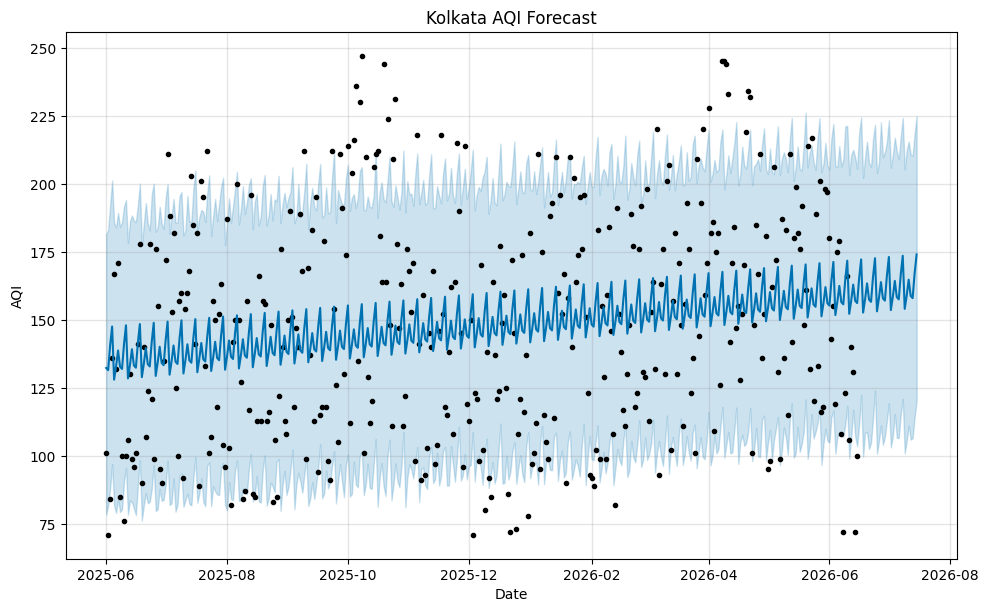

In [62]:
fig = model.plot(forecast)
plt.title("Kolkata AQI Forecast")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

### Step 9: Check the data types of the forecast DataFrame

In [63]:
forecast.dtypes

ds                            datetime64[ns]
trend                                float64
yhat_lower                           float64
yhat_upper                           float64
trend_lower                          float64
trend_upper                          float64
additive_terms                       float64
additive_terms_lower                 float64
additive_terms_upper                 float64
weekly                               float64
weekly_lower                         float64
weekly_upper                         float64
multiplicative_terms                 float64
multiplicative_terms_lower           float64
multiplicative_terms_upper           float64
yhat                                 float64
dtype: object

### Step 10: See the "Maximum" and "Minimum" Date In Forecast

In [64]:
print(forecast['ds'].max())
print(forecast['ds'].min())

2026-07-15 00:00:00
2025-06-01 00:00:00


In [65]:
forecast.loc[forecast['ds'].dt.date == pd.to_datetime('2026-07-15').date(),['ds', 'yhat']]

,ds,yhat
409,2026-07-15,174.027108


### Step 11: Train a Prophet Model for Every City

In [66]:
# Create folder for models
os.makedirs("../aqi_models", exist_ok=True)

cities = Weather_Data['City'].unique()

for city in cities:

    city_data = Weather_Data[Weather_Data['City'] == city][['Date', 'AQI']].copy()
    city_data.columns = ['ds', 'y']

    model = Prophet()
    model.fit(city_data)

    with open(f"../aqi_models/{city}_forecast.json","w") as fout:
        fout.write(model_to_json(model))

    print(f"{city} model saved")

00:44:22 - cmdstanpy - INFO - Chain [1] start processing
00:44:22 - cmdstanpy - INFO - Chain [1] done processing


Ahmedabad model saved


00:44:23 - cmdstanpy - INFO - Chain [1] start processing
00:44:23 - cmdstanpy - INFO - Chain [1] done processing
00:44:23 - cmdstanpy - INFO - Chain [1] start processing


Bengaluru model saved


00:44:23 - cmdstanpy - INFO - Chain [1] done processing


Bhopal model saved


00:44:23 - cmdstanpy - INFO - Chain [1] start processing
00:44:23 - cmdstanpy - INFO - Chain [1] done processing
00:44:24 - cmdstanpy - INFO - Chain [1] start processing


Chennai model saved


00:44:24 - cmdstanpy - INFO - Chain [1] done processing
00:44:24 - cmdstanpy - INFO - Chain [1] start processing
00:44:24 - cmdstanpy - INFO - Chain [1] done processing


Delhi model saved


00:44:24 - cmdstanpy - INFO - Chain [1] start processing


Goa model saved


00:44:24 - cmdstanpy - INFO - Chain [1] done processing
00:44:24 - cmdstanpy - INFO - Chain [1] start processing


Hyderabad model saved


00:44:25 - cmdstanpy - INFO - Chain [1] done processing
00:44:25 - cmdstanpy - INFO - Chain [1] start processing
00:44:25 - cmdstanpy - INFO - Chain [1] done processing


Jaipur model saved
Kanpur model saved


00:44:25 - cmdstanpy - INFO - Chain [1] start processing
00:44:25 - cmdstanpy - INFO - Chain [1] done processing
00:44:25 - cmdstanpy - INFO - Chain [1] start processing
00:44:25 - cmdstanpy - INFO - Chain [1] done processing


Kochi model saved
Kolkata model saved


00:44:25 - cmdstanpy - INFO - Chain [1] start processing
00:44:25 - cmdstanpy - INFO - Chain [1] done processing
00:44:25 - cmdstanpy - INFO - Chain [1] start processing
00:44:26 - cmdstanpy - INFO - Chain [1] done processing


Lucknow model saved
Mumbai model saved


00:44:26 - cmdstanpy - INFO - Chain [1] start processing
00:44:26 - cmdstanpy - INFO - Chain [1] done processing
00:44:26 - cmdstanpy - INFO - Chain [1] start processing
00:44:26 - cmdstanpy - INFO - Chain [1] done processing


Mysuru model saved
Nagpur model saved


00:44:26 - cmdstanpy - INFO - Chain [1] start processing
00:44:26 - cmdstanpy - INFO - Chain [1] done processing
00:44:26 - cmdstanpy - INFO - Chain [1] start processing


Patna model saved


00:44:26 - cmdstanpy - INFO - Chain [1] done processing
00:44:27 - cmdstanpy - INFO - Chain [1] start processing


Pune model saved


00:44:27 - cmdstanpy - INFO - Chain [1] done processing
00:44:27 - cmdstanpy - INFO - Chain [1] start processing


Surat model saved


00:44:27 - cmdstanpy - INFO - Chain [1] done processing
00:44:27 - cmdstanpy - INFO - Chain [1] start processing


Varanasi model saved


00:44:27 - cmdstanpy - INFO - Chain [1] done processing


Visakhapatnam model saved
